# Tutorial 1: Galacticus as a cosmology calculator

[Galacticus](https://github.com/galacticusorg/galacticus) is a semi-analytic
model of galaxy formation. Its physics engine — every `functionClass` of the
Fortran code, from cosmology through dark-matter halos to stellar
populations — is exposed to Python through the `libgalacticus` shared
library, so you can use the *same* implementations that power full galaxy
formation runs as building blocks in your own scripts and notebooks.

This first tutorial introduces the two ideas you need:

1. **Objects are built from parameter values and other objects.** Galacticus
   is organized around abstract classes (`cosmologyParameters`,
   `cosmologyFunctions`, `transferFunction`, …), each with interchangeable
   implementations. In Python you instantiate an implementation by calling
   its constructor with plain values and previously-constructed objects.
2. **Methods are ordinary Python calls** returning floats, numpy arrays, or
   tuples.

Here we drive the cosmology classes: expansion history, times, densities,
and distances.

**Units** (Galacticus conventions): masses in $M_\odot$, times in Gyr,
distances in Mpc, $H_0$ in km/s/Mpc, wavenumbers in comoving Mpc$^{-1}$.

## Setup

Load the library. If you built Galacticus from source with
`make GALACTICUS_BUILD_OPTION=lib libgalacticus.so` and are running this
notebook from the `tutorials/` folder of the source tree, this cell works
as-is; otherwise point `GALACTICUS_LIBRARY_PATH` at the directory containing
the `galacticus/` folder of the binary distribution.

> **Troubleshooting — `OSError: ... version 'GCC_x.y.0' not found`.**
> `libgalacticus.so` links against your compiler's C++/GCC runtime
> (`libstdc++.so.6`, `libgcc_s.so.1`); if your Python environment loads older
> copies, importing `galacticus` fails with, e.g.,
> `` libgcc_s.so.1: version `GCC_14.0.0' not found ``. In a shell an
> `LD_PRELOAD=/path/to/compiler/lib64/libstdc++.so.6 python3 ...` fixes it,
> but **that cannot be done from a notebook cell**: the linker reads
> `LD_PRELOAD` only at process startup, and the kernel has already loaded the
> old libraries before this cell runs. Instead, create a dedicated Jupyter
> kernel whose `kernel.json` sets `LD_PRELOAD` (to the correct
> `libgcc_s.so.1` and `libstdc++.so.6`) in its `env` block, and select it via
> Kernel → Change Kernel. See the "Troubleshooting" section of
> [`README.md`](README.md) for the exact `kernel.json`.

In [1]:
import os, sys

# Locate the Galacticus library interface. Two supported layouts:
#  * a Galacticus source tree built with
#      make GALACTICUS_BUILD_OPTION=lib libgalacticus.so
#    (galacticus.py at the tree root, the library under galacticus/lib/);
#  * an unpacked binary distribution (the `galacticus/` folder from
#    libgalacticus.tar.bz2, with python/ and lib/ inside it).
# Set GALACTICUS_LIBRARY_PATH to the directory CONTAINING the `galacticus/`
# folder if the auto-detection below does not fit your setup.
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## Cosmological parameters

The `cosmologyParametersSimple` implementation holds a flat set of
parameters: $\Omega_\mathrm{M}$, $\Omega_\mathrm{b}$,
$\Omega_\Lambda$, $T_\mathrm{CMB}$ [K], and $H_0$ [km/s/Mpc].

In [3]:
cosmologyParameters = galacticus.cosmologyParametersSimple(
    OmegaMatter    = 0.3,
    OmegaBaryon    = 0.045,
    OmegaDarkEnergy= 0.7,
    temperatureCMB = 2.78,
    HubbleConstant = 70.0,
)
print(f"Omega_M          = {cosmologyParameters.OmegaMatter():.3f}")
print(f"Omega_b          = {cosmologyParameters.OmegaBaryon():.3f}")
print(f"Omega_DE         = {cosmologyParameters.OmegaDarkEnergy():.3f}")
print(f"Omega_curvature  = {cosmologyParameters.OmegaCurvature():.3f}")
print(f"H_0              = {cosmologyParameters.HubbleConstant():.1f} km/s/Mpc")
print(f"critical density = {cosmologyParameters.densityCritical():.4e} Msun/Mpc^3")

Omega_M          = 0.300
Omega_b          = 0.045
Omega_DE         = 0.700
Omega_curvature  = 0.000
H_0              = 70.0 km/s/Mpc
critical density = 1.3598e+11 Msun/Mpc^3


## Expansion history

`cosmologyFunctionsMatterLambda` solves the Friedmann equation for a
matter + cosmological-constant universe. It is constructed *from* the
parameters object — this dependency-injection pattern is how every
Galacticus object graph is assembled.

In [4]:
cosmologyFunctions = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)

ageToday = cosmologyFunctions.cosmicTime(1.0)      # time at expansion factor a=1
print(f"Age of the Universe today : {ageToday:.3f} Gyr")
for z in (0.5, 2.0, 6.0, 20.0):
    a = cosmologyFunctions.expansionFactorFromRedshift(z)
    t = cosmologyFunctions.cosmicTime(a)
    print(f"  z = {z:5.1f}  ->  a = {a:.4f},  t = {t:6.3f} Gyr,"
          f"  H = {cosmologyFunctions.hubbleParameterEpochal(time=t):7.1f} km/s/Mpc")

Age of the Universe today : 13.467 Gyr
  z =   0.5  ->  a = 0.6667,  t =  8.426 Gyr,  H =    91.6 km/s/Mpc
  z =   2.0  ->  a = 0.3333,  t =  3.227 Gyr,  H =   207.7 km/s/Mpc
  z =   6.0  ->  a = 0.1429,  t =  0.917 Gyr,  H =   712.5 km/s/Mpc
  z =  20.0  ->  a = 0.0476,  t =  0.177 Gyr,  H =  3690.1 km/s/Mpc


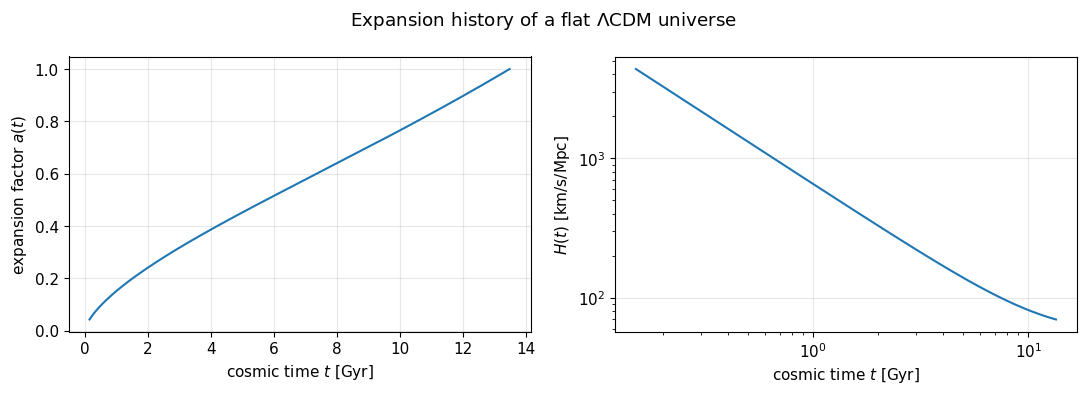

In [5]:
# Expansion factor and Hubble rate through cosmic time.
times = np.linspace(0.15, ageToday, 300)
a     = np.array([cosmologyFunctions.expansionFactor(t)                for t in times])
H     = np.array([cosmologyFunctions.hubbleParameterEpochal(time=t)   for t in times])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times, a)
axes[0].set_xlabel('cosmic time $t$ [Gyr]'); axes[0].set_ylabel('expansion factor $a(t)$')
axes[1].loglog(times, H)
axes[1].set_xlabel('cosmic time $t$ [Gyr]'); axes[1].set_ylabel('$H(t)$ [km/s/Mpc]')
fig.suptitle('Expansion history of a flat $\\Lambda$CDM universe')
fig.tight_layout()
plt.show()

## The changing energy budget

$\Omega_\mathrm{M}(t)$ and $\Omega_\Lambda(t)$ trade places around
$z \sim 0.3$: matter domination gives way to dark-energy domination, which
is why structure growth slows at late times (Tutorial 2).

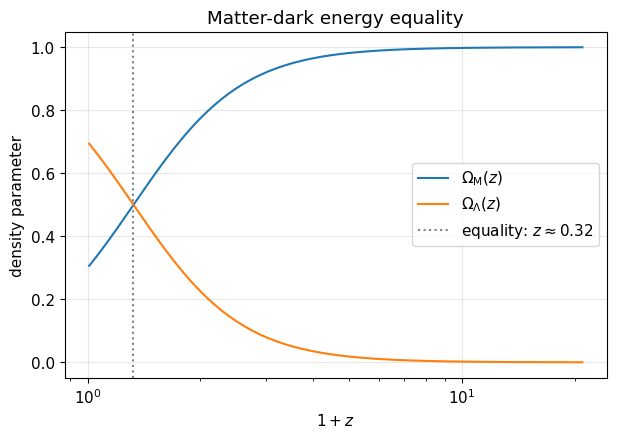

In [6]:
zGrid = np.logspace(-2, 1.3, 200)
tGrid = np.array([cosmologyFunctions.cosmicTime(
                      cosmologyFunctions.expansionFactorFromRedshift(z)) for z in zGrid])
OmegaM  = np.array([cosmologyFunctions.omegaMatterEpochal   (time=t) for t in tGrid])
OmegaDE = np.array([cosmologyFunctions.omegaDarkEnergyEpochal(time=t) for t in tGrid])

plt.semilogx(1.0+zGrid, OmegaM , label='$\\Omega_\\mathrm{M}(z)$')
plt.semilogx(1.0+zGrid, OmegaDE, label='$\\Omega_\\Lambda(z)$')
zEq = zGrid[np.argmin(np.abs(OmegaM-OmegaDE))]
plt.axvline(1.0+zEq, color='gray', ls=':', label=f'equality: $z\\approx{zEq:.2f}$')
plt.xlabel('$1+z$'); plt.ylabel('density parameter'); plt.legend()
plt.title('Matter-dark energy equality')
plt.show()

## Distances

Galacticus's distance functions take cosmic *time* as their argument; use
`expansionFactorFromRedshift` + `cosmicTime` to convert from redshift. The
familiar textbook relations between comoving, luminosity, and angular
diameter distances hold: $d_\mathrm{L} = (1+z)\,d_\mathrm{C}$ and
$d_\mathrm{A} = d_\mathrm{C}/(1+z)$ in a flat universe.

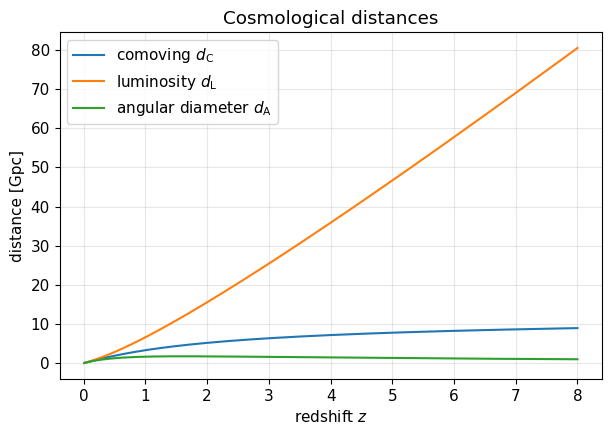

d_L=(1+z)d_C and d_A=d_C/(1+z) verified at z=2.02


In [7]:
zGrid = np.linspace(0.01, 8.0, 200)
tGrid = np.array([cosmologyFunctions.cosmicTime(
                      cosmologyFunctions.expansionFactorFromRedshift(z)) for z in zGrid])
dC = np.array([cosmologyFunctions.distanceComoving  (t) for t in tGrid])
dL = np.array([cosmologyFunctions.distanceLuminosity(t) for t in tGrid])
dA = np.array([cosmologyFunctions.distanceAngular   (t) for t in tGrid])

plt.plot(zGrid, dC/1.0e3, label='comoving $d_\\mathrm{C}$')
plt.plot(zGrid, dL/1.0e3, label='luminosity $d_\\mathrm{L}$')
plt.plot(zGrid, dA/1.0e3, label='angular diameter $d_\\mathrm{A}$')
plt.xlabel('redshift $z$'); plt.ylabel('distance [Gpc]'); plt.legend()
plt.title('Cosmological distances')
plt.show()

# Internal consistency checks.
i = np.argmin(np.abs(zGrid-2.0)); z = zGrid[i]
assert np.isclose(dL[i], (1.0+z)   *dC[i], rtol=1.0e-6)
assert np.isclose(dA[i],  dC[i]/(1.0+z)  , rtol=1.0e-6)
print(f"d_L=(1+z)d_C and d_A=d_C/(1+z) verified at z={z:.2f}")

## Comparing cosmologies

Because objects are cheap to construct, comparing cosmologies is a
two-line affair. Here: our fiducial flat $\Lambda$CDM against an
Einstein-de Sitter universe ($\Omega_\mathrm{M}=1$).

Age of the Universe:  LCDM = 13.467 Gyr,  EdS =  9.312 Gyr


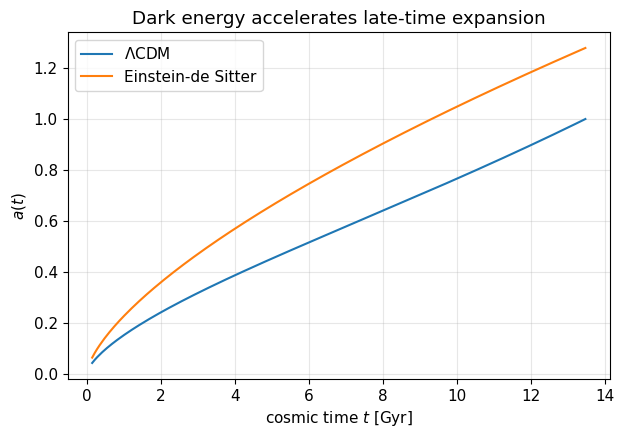

In [8]:
cosmologyParametersEdS = galacticus.cosmologyParametersSimple(1.0, 0.045, 0.0, 2.78, 70.0)
cosmologyFunctionsEdS  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParametersEdS)

print(f"Age of the Universe:  LCDM = {cosmologyFunctions.cosmicTime(1.0):6.3f} Gyr,"
      f"  EdS = {cosmologyFunctionsEdS.cosmicTime(1.0):6.3f} Gyr")

times = np.linspace(0.15, ageToday, 200)
for label, cf in (('$\\Lambda$CDM', cosmologyFunctions), ('Einstein-de Sitter', cosmologyFunctionsEdS)):
    plt.plot(times, [cf.expansionFactor(t) for t in times], label=label)
plt.xlabel('cosmic time $t$ [Gyr]'); plt.ylabel('$a(t)$'); plt.legend()
plt.title('Dark energy accelerates late-time expansion')
plt.show()

## Where next

* **Tutorial 2** builds the linear matter power spectrum from these same
  objects — including warm-dark-matter variants.
* **Tutorial 3** computes halo mass functions across cosmic time.
* **Tutorial 4** shows Galacticus calling back into *your* Python functions.